# SentinelGuard Week 2 - SMOTE and XGBoost Training
Sudarshan Sangle | 25234760 | University of Galway

This is the second notebook. Week 1 was loading and cleaning the data. Now I'm actually training the model. Starting with a basic XGBoost with no tuning just to see what numbers I get, then I'll improve it in the next notebook.

## setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


loading the processed saved file

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Project/sentinelguard_processed.csv')

print('rows:', len(df))
print('columns:', list(df.columns))
print('fraud rate:', round(df['isFraud'].mean() * 100, 4), '%')

rows: 2770409
columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'balance_change_orig', 'hour', 'amount_ratio', 'outside_hours', 'account_emptied', 'recipient_risk_score']
fraud rate: 0.2965 %


In [4]:
# install what I need
!pip install xgboost imbalanced-learn --quiet
print('installed')

installed


## splitting the data

Doing this before SMOTE otherwise the test set gets contaminated with synthetic data which would make results look better than they really are

In [5]:
from sklearn.model_selection import train_test_split

FEATURES = [
    'amount_ratio',
    'outside_hours',
    'account_emptied',
    'recipient_risk_score',
    'oldbalanceOrg',
    'newbalanceOrig'
]
TARGET = 'isFraud'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('train:', len(X_train), '| test:', len(X_test))
print('fraud in train:', y_train.sum())
print('fraud in test:', y_test.sum())

train: 2216327 | test: 554082
fraud in train: 6570
fraud in test: 1643


## SMOTE

The training data has 0.13% fraud which means for every fraud transaction there are about 770 normal ones. If I train on this the model just predicts normal every time and gets 99.87% accuracy which is completely useless.

SMOTE fixes this by generating synthetic fraud samples by blending existing ones together. Only applying it to training data.

In [6]:
from imblearn.over_sampling import SMOTE

print('before SMOTE')
print('  normal:', (y_train == 0).sum())
print('  fraud:', (y_train == 1).sum())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print()
print('after SMOTE')
print('  normal:', (y_train_bal == 0).sum())
print('  fraud:', (y_train_bal == 1).sum())

before SMOTE
  normal: 2209757
  fraud: 6570

after SMOTE
  normal: 2209757
  fraud: 2209757


## training baseline XGBoost

Using all default settings first. Just want to see what the numbers look like before doing any tuning. This gives me something to compare against later.

In [7]:
import xgboost as xgb

model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train_bal, y_train_bal)
print('model trained')

model trained


## results on test set

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print('AUC:', round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.46      1.00      0.63      1643

    accuracy                           1.00    554082
   macro avg       0.73      1.00      0.81    554082
weighted avg       1.00      1.00      1.00    554082

AUC: 0.9983


confusion matrix to see where it goes wrong

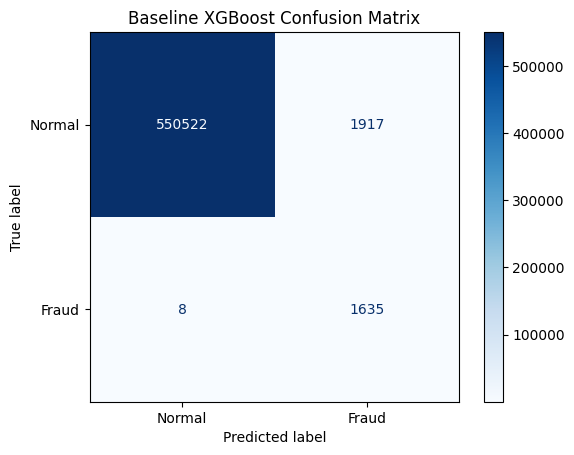

fraud caught: 1635
fraud missed: 8
normal wrongly flagged: 1917
false positive rate: 0.347 %


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Baseline XGBoost Confusion Matrix')
plt.savefig('baseline_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print('fraud caught:', tp)
print('fraud missed:', fn)
print('normal wrongly flagged:', fp)
print('false positive rate:', round(fp / (fp + tn) * 100, 4), '%')

which features does it rely on most

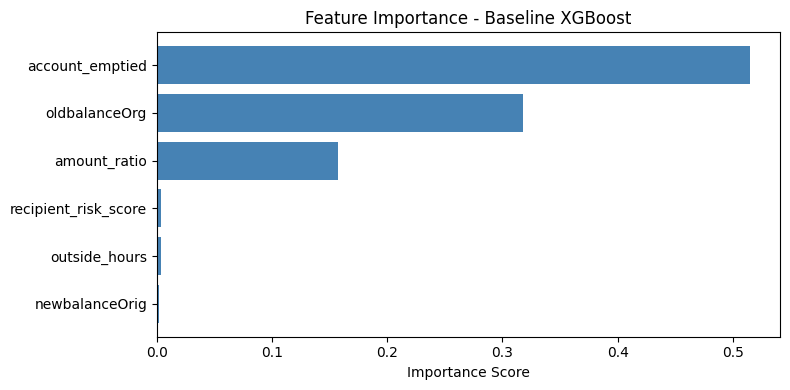

             feature  importance
     account_emptied    0.515096
       oldbalanceOrg    0.318001
        amount_ratio    0.157233
recipient_risk_score    0.003880
       outside_hours    0.003656
      newbalanceOrig    0.002135


In [10]:
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('Feature Importance - Baseline XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print(importance.sort_values('importance', ascending=False).to_string(index=False))

## save model and test set

Saving everything to drive so I can load it in the next notebook without retraining from scratch

In [11]:
import pickle

report = classification_report(y_test, y_pred, output_dict=True)

baseline = {
    'precision': round(report['1']['precision'], 4),
    'recall': round(report['1']['recall'], 4),
    'f1': round(report['1']['f1-score'], 4),
    'auc': round(roc_auc_score(y_test, y_prob), 4)
}

print('baseline results')
for k, v in baseline.items():
    print(' ', k, v)

print()
print('target precision >= 0.95')

baseline results
  precision 0.4603
  recall 0.9951
  f1 0.6295
  auc 0.9983

target precision >= 0.95


In [12]:
with open('/content/drive/MyDrive/Project/xgb_baseline.pkl', 'wb') as f:
    pickle.dump(model, f)

X_test.to_csv('/content/drive/MyDrive/Project/X_test.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/Project/y_test.csv', index=False)

print('saved xgb_baseline.pkl')
print('saved X_test.csv and y_test.csv')

saved xgb_baseline.pkl
saved X_test.csv and y_test.csv


## notes

Baseline is done. Got first real precision/recall/AUC numbers.

Next notebook is Week 3 - Optuna hyperparameter tuning to improve these numbers, then adding Isolation Forest as an extra feature to help catch unusual transactions the model hasn't seen before.